<a href="https://colab.research.google.com/github/Hoppdie/d2c-churn-part1/blob/main/eda_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1 — Data Audit, EDA & Business Understanding
**D2C Customer Churn Intelligence Capstone**

**Snapshot date:** `2025-09-30`  
**Target:** `churn_next_60d` — did the customer make zero purchases between `2025-10-01` and `2025-11-29`?

---
### Notebook Structure
1. Setup & Data Loading
2. Schema Inspection
3. Data Quality Audit
4. Exploratory Data Analysis
5. Churn-Risk Hypotheses (5 evidenced)
6. Summary of Findings


## 1. Setup & Data Loading

In [11]:
# Install / import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# ── Plotting defaults ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (10, 4),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

SNAPSHOT = pd.Timestamp('2025-09-30')
print('Libraries loaded ✓')

Libraries loaded ✓


In [12]:
# ── Mount Google Drive ─────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# !! UPDATE this path to wherever you saved the data package in your Drive
DATA_DIR =  '/content/drive/MyDrive/D2C Churn Capstone'   # <── change if needed

import os
files = os.listdir(DATA_DIR)
print('Files found:', sorted(files))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files found: ['DATA_DICTIONARY.md', 'Part 1 - Data Audit EDA', 'Part 2', 'Part 3', 'Part 4', 'STUDENT_FACING_PROBLEM_STATEMENT.md', 'churn_labels.csv', 'customers.csv', 'intervention_history.csv', 'orders.csv', 'rfm_modeling_snapshot.csv', 'support_tickets.csv', 'web_events_snapshot.csv']


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os

# ── Load all datasets ──────────────────────────────────────────────────────────
customers    = pd.read_csv(os.path.join(DATA_DIR, 'customers.csv'))
orders       = pd.read_csv(os.path.join(DATA_DIR, 'orders.csv'),       parse_dates=['order_date'])
tickets      = pd.read_csv(os.path.join(DATA_DIR, 'support_tickets.csv'), parse_dates=['ticket_date'])
web          = pd.read_csv(os.path.join(DATA_DIR, 'web_events_snapshot.csv'))
labels       = pd.read_csv(os.path.join(DATA_DIR, 'churn_labels.csv'))
rfm_snap     = pd.read_csv(os.path.join(DATA_DIR, 'rfm_modeling_snapshot.csv'))
interventions= pd.read_csv(os.path.join(DATA_DIR, 'intervention_history.csv'))

datasets = {
    'customers':     customers,
    'orders':        orders,
    'tickets':       tickets,
    'web_events':    web,
    'churn_labels':  labels,
    'rfm_snapshot':  rfm_snap,
    'interventions': interventions,
}

print(f"{'Dataset':<20} {'Rows':>7} {'Cols':>6}")
print('-' * 36)
for name, df in datasets.items():
    print(f"{name:<20} {df.shape[0]:>7,} {df.shape[1]:>6}")

Dataset                 Rows   Cols
------------------------------------
customers              2,400      9
orders                10,009     10
tickets                1,921      8
web_events             2,400     10
churn_labels           2,400      4
rfm_snapshot           2,400     29
interventions          2,400      5


## 2. Schema Inspection

In [15]:
# ── Print dtypes and sample for each dataset ──────────────────────────────────
for name, df in datasets.items():
    print(f'\n{'='*60}')
    print(f'  {name.upper()}  ({df.shape[0]:,} rows × {df.shape[1]} cols)')
    print(f'{'='*60}')
    print(df.dtypes.to_string())
    print('\nSample (3 rows):')
    display(df.head(3))


  CUSTOMERS  (2,400 rows × 9 cols)
customer_id            object
signup_date            object
city_tier              object
age_group              object
acquisition_channel    object
loyalty_tier           object
preferred_category     object
skin_type              object
marketing_consent      object

Sample (3 rows):


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes



  ORDERS  (10,009 rows × 10 cols)
order_id                 object
customer_id              object
order_date       datetime64[ns]
category                 object
quantity                  int64
gross_amount            float64
discount_pct            float64
delivery_days             int64
returned                  int64
rating                  float64

Sample (3 rows):


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0



  TICKETS  (1,921 rows × 8 cols)
ticket_id                   object
customer_id                 object
ticket_date         datetime64[ns]
issue_type                  object
support_channel             object
resolution_hours           float64
sentiment_score            float64
reopened                     int64

Sample (3 rows):


...

,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train



  RFM_SNAPSHOT  (2,400 rows × 29 cols)
customer_id                  object
snapshot_date                object
city_tier                    object
age_group                    object
acquisition_channel          object
loyalty_tier                 object
preferred_category           object
marketing_consent            object
recency_days                  int64
frequency_180d                int64
monetary_180d               float64
return_rate_180d            float64
avg_discount_pct_180d       float64
avg_rating_180d             float64
category_diversity_180d       int64
ticket_count_90d              int64
negative_ticket_rate_90d    float64
avg_resolution_hours_90d    float64
days_since_signup             int64
sessions_30d                  int64
product_views_30d             int64
cart_adds_30d                 int64
wishlist_adds_30d             int64
abandoned_carts_30d           int64
email_opens_30d               int64
campaign_clicks_30d           int64
last_visit_days_ago     

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train



  INTERVENTIONS  (2,400 rows × 5 cols)
customer_id               object
snapshot_date             object
last_campaign_received    object
last_campaign_cost         int64
manual_priority_bucket    object

Sample (3 rows):


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high


In [16]:
# ── Join coverage check ────────────────────────────────────────────────────────
# All joins are LEFT from customers (2,400 is the universe)
universe = set(customers['customer_id'])

for name, df in datasets.items():
    if 'customer_id' in df.columns and name != 'customers':
        matched   = df['customer_id'].isin(universe).sum()
        unmatched = (~df['customer_id'].isin(universe)).sum()
        coverage  = matched / len(df) * 100
        print(f"{name:<20}  matched={matched:,}  unmatched={unmatched}  coverage={coverage:.1f}%")

orders                matched=10,009  unmatched=0  coverage=100.0%
tickets               matched=1,921  unmatched=0  coverage=100.0%
web_events            matched=2,400  unmatched=0  coverage=100.0%
churn_labels          matched=2,400  unmatched=0  coverage=100.0%
rfm_snapshot          matched=2,400  unmatched=0  coverage=100.0%
interventions         matched=2,400  unmatched=0  coverage=100.0%


## 3. Data Quality Audit

In [17]:
# ── 3.1  Missing values ────────────────────────────────────────────────────────
print('MISSING VALUE SUMMARY\n')
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f'{name}:')
        for col, cnt in missing.items():
            pct = cnt / len(df) * 100
            print(f'   {col:<30} {cnt:>5} missing ({pct:.1f}%)')
        print()

MISSING VALUE SUMMARY

customers:
   loyalty_tier                    1386 missing (57.8%)
   skin_type                        401 missing (16.7%)

orders:
   rating                            80 missing (0.8%)

rfm_snapshot:
   loyalty_tier                    1386 missing (57.8%)



In [18]:
# ── 3.2  Duplicate / duplicate-like records in orders ─────────────────────────
dup_flag   = orders['order_id'].str.endswith('_DUP')
n_dup      = dup_flag.sum()
n_exact    = orders.duplicated().sum()

print(f'Orders with _DUP suffix  : {n_dup}')
print(f'Exact duplicate rows     : {n_exact}')
print(f'Total orders (raw)       : {len(orders):,}')

# Strip DUP rows for all analysis (keep only clean orders)
orders_clean = orders[~dup_flag].copy()
print(f'\nClean orders (after removing _DUP): {len(orders_clean):,}')

Orders with _DUP suffix  : 12
Exact duplicate rows     : 0
Total orders (raw)       : 10,009

Clean orders (after removing _DUP): 9,997


In [19]:
# ── 3.3  Post-snapshot order leakage check ─────────────────────────────────────
post_snap = orders_clean[orders_clean['order_date'] > SNAPSHOT]
pre_snap  = orders_clean[orders_clean['order_date'] <= SNAPSHOT]

print(f'Pre-snapshot orders  (safe to use as features): {len(pre_snap):,}')
print(f'Post-snapshot orders (label construction only): {len(post_snap):,}')
print(f'\nPost-snapshot date range: {post_snap["order_date"].min().date()} → {post_snap["order_date"].max().date()}')

# All EDA and feature work uses only pre-snapshot orders
orders_pre = pre_snap.copy()
print('\norders_pre defined — all downstream analysis uses this.')

Pre-snapshot orders  (safe to use as features): 8,128
Post-snapshot orders (label construction only): 1,869

Post-snapshot date range: 2025-10-01 → 2025-11-29

orders_pre defined — all downstream analysis uses this.


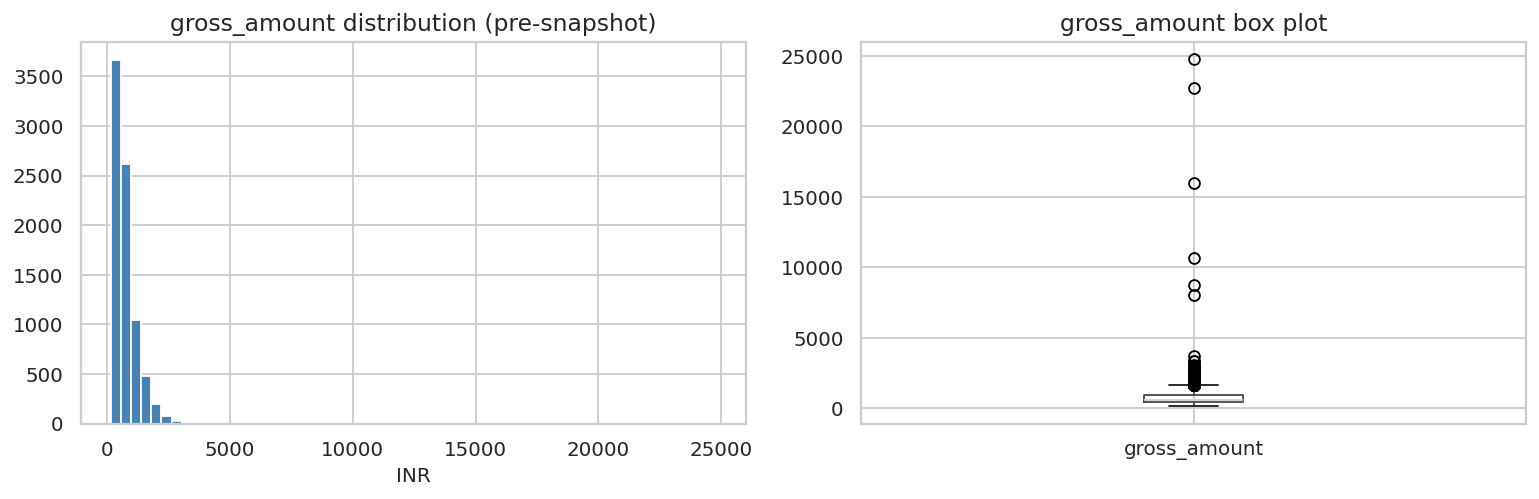

99th percentile: ₹2,343
Orders above 99th pct: 82 (1.0%)
Max value: ₹24,789


In [20]:
# ── 3.4  Outlier check: gross_amount ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

orders_pre['gross_amount'].hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('gross_amount distribution (pre-snapshot)')
axes[0].set_xlabel('INR')

orders_pre.boxplot(column='gross_amount', ax=axes[1])
axes[1].set_title('gross_amount box plot')

plt.tight_layout()
plt.savefig('chart_01_gross_amount_outliers.png', bbox_inches='tight')
plt.show()

q99 = orders_pre['gross_amount'].quantile(0.99)
outliers = orders_pre[orders_pre['gross_amount'] > q99]
print(f'99th percentile: ₹{q99:,.0f}')
print(f'Orders above 99th pct: {len(outliers)} ({len(outliers)/len(orders_pre)*100:.1f}%)')
print(f'Max value: ₹{orders_pre["gross_amount"].max():,.0f}')

In [21]:
# ── 3.5  loyalty_tier and skin_type null pattern ─────────────────────────────
# Are nulls in loyalty_tier correlated with churn?
cust_labels = customers.merge(labels[['customer_id','churn_next_60d']], on='customer_id')

loyalty_null_churn = cust_labels.groupby(cust_labels['loyalty_tier'].isna())['churn_next_60d'].mean()
loyalty_null_churn.index = ['Enrolled', 'Not Enrolled (null)']
print('Churn rate by loyalty enrolment:')
print(loyalty_null_churn.round(3))

print(f'\nCustomers NOT enrolled in loyalty programme: {cust_labels["loyalty_tier"].isna().sum():,} '
      f'({cust_labels["loyalty_tier"].isna().mean()*100:.1f}%)')

Churn rate by loyalty enrolment:
Enrolled               0.451
Not Enrolled (null)    0.483
Name: churn_next_60d, dtype: float64

Customers NOT enrolled in loyalty programme: 1,386 (57.8%)


In [22]:
# ── 3.6  Date consistency checks ─────────────────────────────────────────────
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

# signup_date should not be after snapshot
future_signups = customers[customers['signup_date'] > SNAPSHOT]
print(f'Customers with signup_date > snapshot: {len(future_signups)}')

# ticket_date should not exceed snapshot
future_tickets = tickets[tickets['ticket_date'] > SNAPSHOT]
print(f'Tickets with ticket_date > snapshot  : {len(future_tickets)}')

print('\nDate consistency: OK — all profile and ticket dates are within bounds.')

Customers with signup_date > snapshot: 0
Tickets with ticket_date > snapshot  : 0

Date consistency: OK — all profile and ticket dates are within bounds.


In [23]:
# ── 3.7  rating null pattern in orders ───────────────────────────────────────
null_rating = orders_pre['rating'].isna()
print(f'Orders with no rating: {null_rating.sum()} ({null_rating.mean()*100:.1f}%)')

# Compare return rate for rated vs unrated
print('\nReturn rate — rated vs unrated orders:')
print(orders_pre.groupby(null_rating)['returned'].mean()
      .rename({False:'Has rating', True:'No rating'}).round(3))

Orders with no rating: 58 (0.7%)

Return rate — rated vs unrated orders:
rating
Has rating    0.065
No rating     0.103
Name: returned, dtype: float64


## 4. Exploratory Data Analysis

### 4A — Churn Distribution & Split

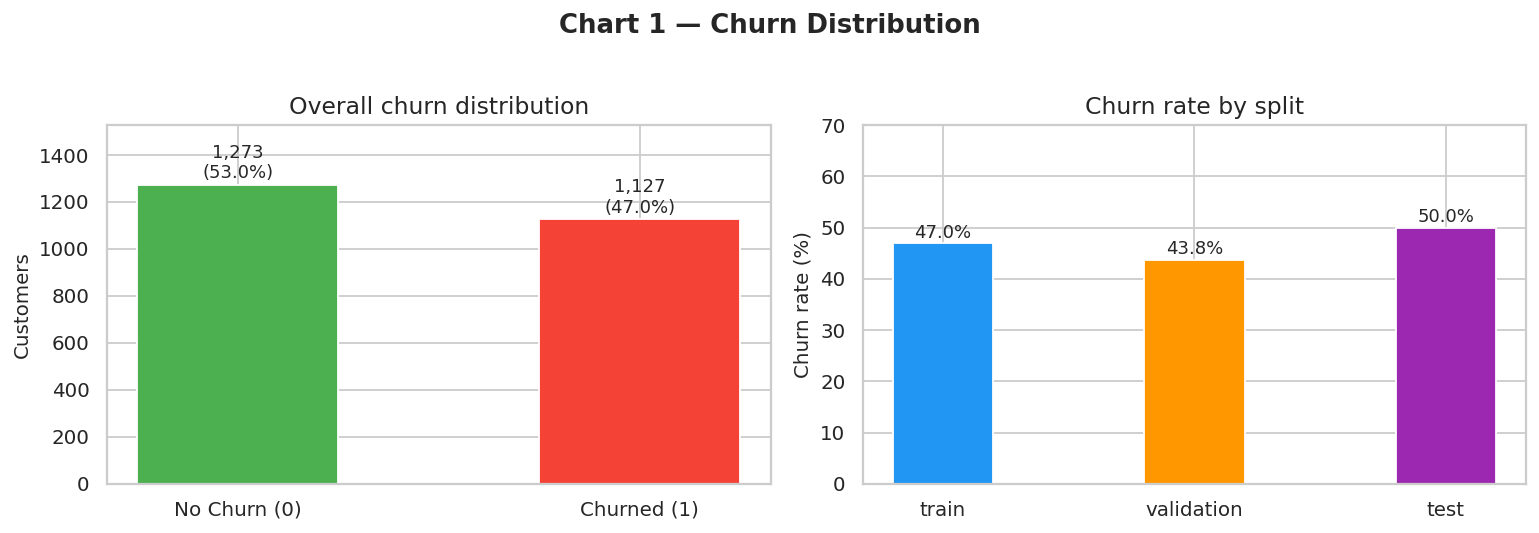

Overall churn rate: 47.0%

Split sizes:
split
train         1728
validation     336
test           336
Name: count, dtype: int64


In [41]:
# ── Chart 1: Churn distribution overall and by split ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall
churn_counts = labels['churn_next_60d'].value_counts().sort_index()
bars = axes[0].bar(['No Churn (0)', 'Churned (1)'], churn_counts.values,
                   color=['#4CAF50', '#F44336'], edgecolor='white', width=0.5)
for bar, v in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{v:,}\n({v/len(labels)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Overall churn distribution')
axes[0].set_ylabel('Customers')
axes[0].set_ylim(0, churn_counts.max() * 1.2)

# By split
split_churn = labels.groupby('split')['churn_next_60d'].mean().reindex(['train','validation','test'])
axes[1].bar(split_churn.index, split_churn.values * 100,
            color=['#2196F3','#FF9800','#9C27B0'], edgecolor='white', width=0.4)
axes[1].set_title('Churn rate by split')
axes[1].set_ylabel('Churn rate (%)')
axes[1].set_ylim(0, 70)
for i, (split, val) in enumerate(split_churn.items()):
    axes[1].text(i, val*100 + 1, f'{val*100:.1f}%', ha='center', fontsize=10)

plt.suptitle('Chart 1 — Churn Distribution', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_02_churn_distribution.png', bbox_inches='tight')
plt.show()

overall_churn = labels['churn_next_60d'].mean()
print(f'Overall churn rate: {overall_churn*100:.1f}%')
print('\nSplit sizes:')
print(labels['split'].value_counts())

### 4B — Customer Profile Analysis

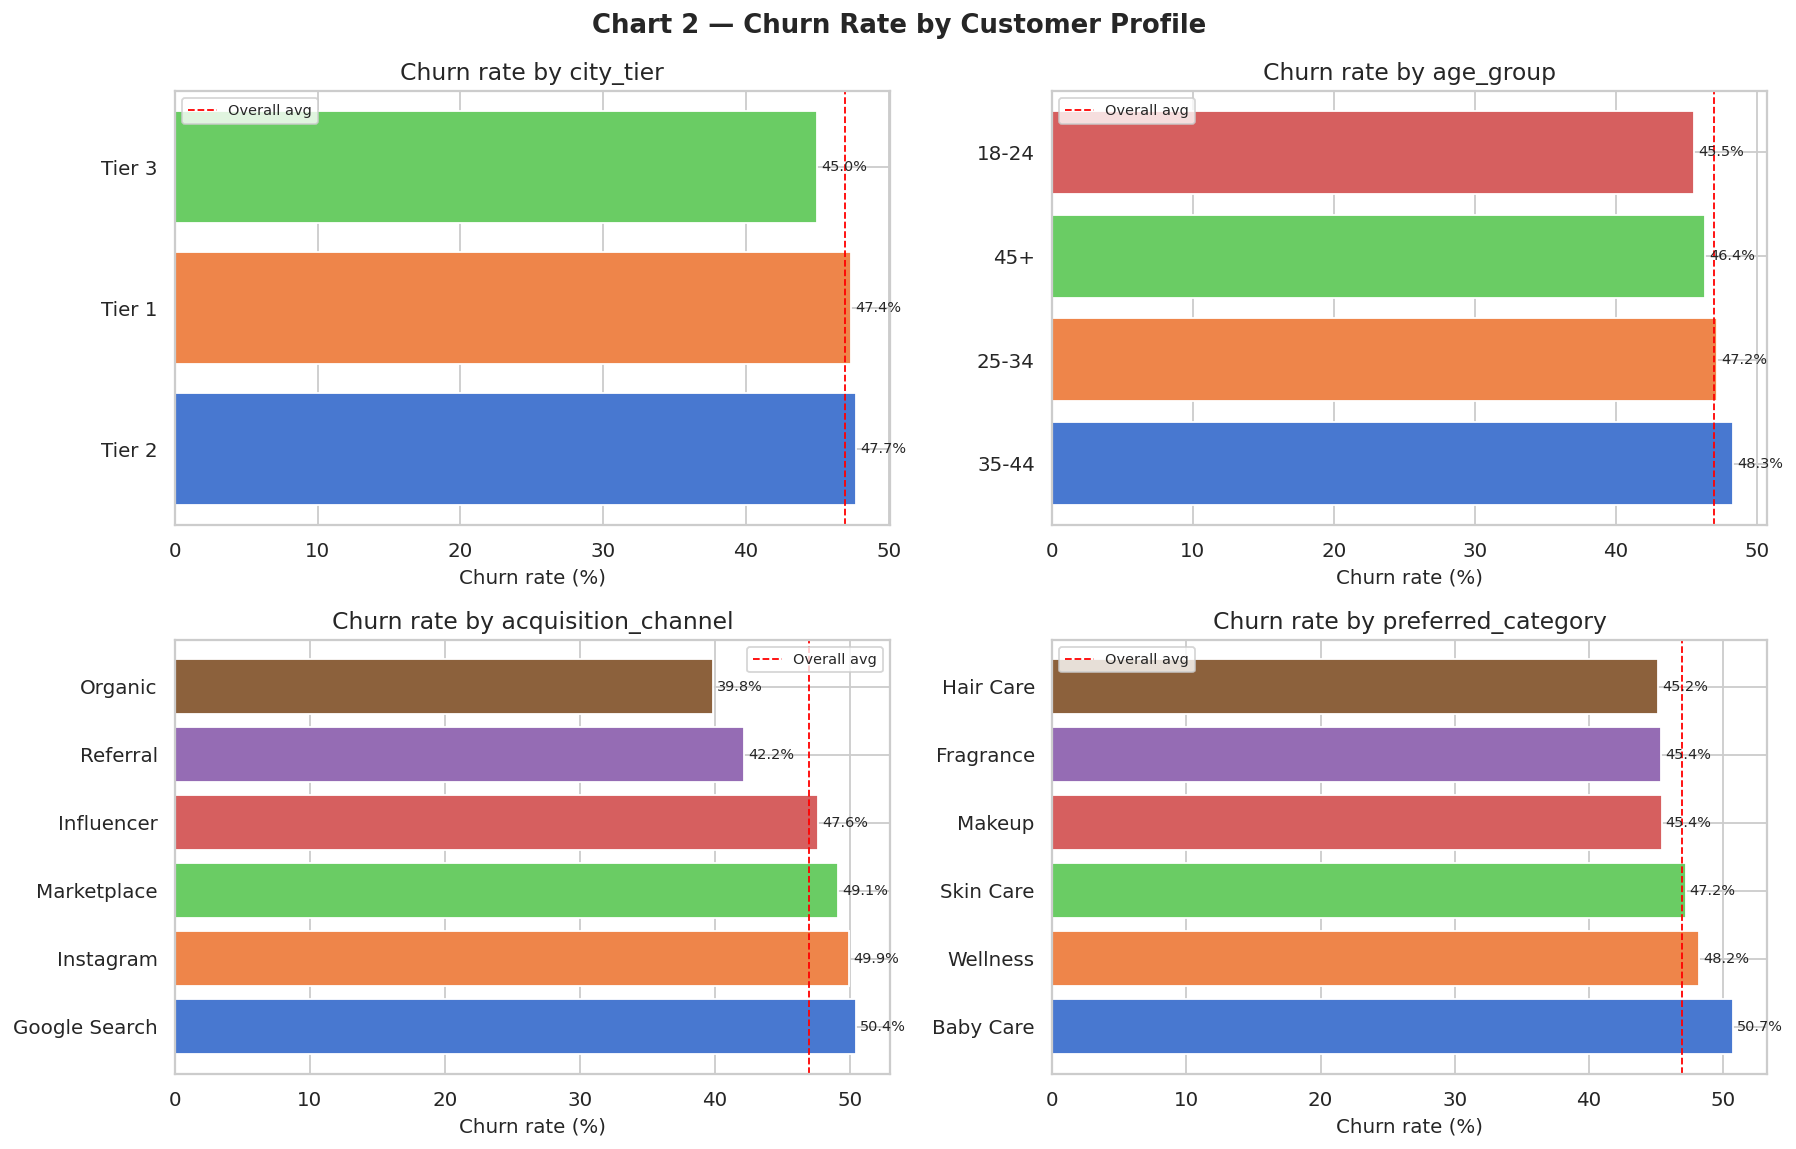

In [42]:
# ── Chart 2: Churn rate by key categorical dimensions ─────────────────────────
cust_full = customers.merge(labels[['customer_id','churn_next_60d']], on='customer_id')

cat_cols = ['city_tier', 'age_group', 'acquisition_channel', 'preferred_category']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    churn_by = cust_full.groupby(col)['churn_next_60d'].mean().sort_values(ascending=False)
    bars = ax.barh(churn_by.index, churn_by.values * 100,
                   color=sns.color_palette('muted', len(churn_by)))
    ax.axvline(overall_churn * 100, color='red', linestyle='--', linewidth=1, label='Overall avg')
    ax.set_title(f'Churn rate by {col}')
    ax.set_xlabel('Churn rate (%)')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, churn_by.values):
        ax.text(val*100 + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val*100:.1f}%', va='center', fontsize=8)

plt.suptitle('Chart 2 — Churn Rate by Customer Profile', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_03_churn_by_profile.png', bbox_inches='tight')
plt.show()

In [43]:
# ── Loyalty tier vs churn (including nulls = not enrolled) ────────────────────
cust_full['loyalty_status'] = cust_full['loyalty_tier'].fillna('Not Enrolled')
loyalty_churn = cust_full.groupby('loyalty_status')['churn_next_60d'].agg(['mean','count'])
loyalty_churn.columns = ['churn_rate', 'n_customers']
loyalty_churn['churn_rate_pct'] = (loyalty_churn['churn_rate'] * 100).round(1)
print('Churn rate by loyalty status:')
display(loyalty_churn.sort_values('churn_rate', ascending=False))

Churn rate by loyalty status:


,churn_rate,n_customers,churn_rate_pct
loyalty_status,,,
Silver,0.488136,590,48.8
Not Enrolled,0.483405,1386,48.3
Gold,0.407524,319,40.8
Platinum,0.371429,105,37.1


### 4C — Order Behaviour Analysis

In [44]:
# ── Build pre-snapshot order features per customer ────────────────────────────
order_features = orders_pre.groupby('customer_id').agg(
    n_orders        = ('order_id', 'count'),
    total_spend     = ('gross_amount', 'sum'),
    avg_order_value = ('gross_amount', 'mean'),
    return_rate     = ('returned', 'mean'),
    avg_discount    = ('discount_pct', 'mean'),
    avg_rating      = ('rating', 'mean'),
    last_order_date = ('order_date', 'max'),
    n_categories    = ('category', 'nunique'),
).reset_index()

order_features['recency_days'] = (SNAPSHOT - order_features['last_order_date']).dt.days
order_features = order_features.merge(labels[['customer_id','churn_next_60d']], on='customer_id', how='left')

# Customers with zero pre-snapshot orders
zero_order_custs = set(customers['customer_id']) - set(order_features['customer_id'])
print(f'Customers with zero pre-snapshot orders: {len(zero_order_custs)}')
print(f'Customers with at least one order: {len(order_features):,}')

Customers with zero pre-snapshot orders: 0
Customers with at least one order: 2,400


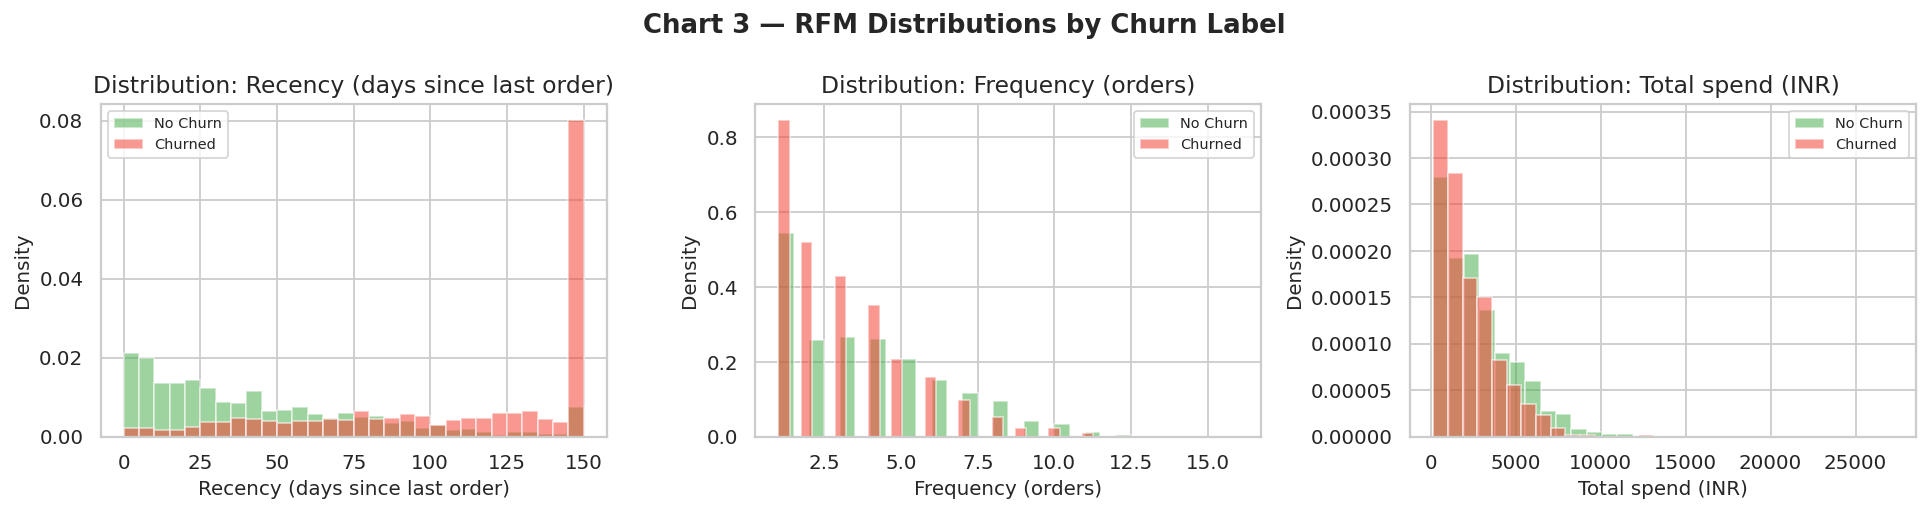


Median values by churn group:


,recency_days,n_orders,total_spend
churn_next_60d,,,
0,32.0,3.0,2333.0
1,125.0,2.0,1724.6


In [45]:
# ── Chart 3: Recency, Frequency, Spend by churn group ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ('recency_days', 'Recency (days since last order)', 150),
    ('n_orders',     'Frequency (orders)',              20),
    ('total_spend',  'Total spend (INR)',               None),
]

for ax, (col, label, cap) in zip(axes, metrics):
    data = order_features.copy()
    if cap:
        data[col] = data[col].clip(upper=cap)
    for churn_val, color, lbl in [(0,'#4CAF50','No Churn'), (1,'#F44336','Churned')]:
        subset = data[data['churn_next_60d'] == churn_val][col].dropna()
        ax.hist(subset, bins=30, alpha=0.55, color=color, label=lbl, density=True)
    ax.set_title(f'Distribution: {label}')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Chart 3 — RFM Distributions by Churn Label', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_04_rfm_by_churn.png', bbox_inches='tight')
plt.show()

print('\nMedian values by churn group:')
display(order_features.groupby('churn_next_60d')[['recency_days','n_orders','total_spend']]
        .median().round(1))

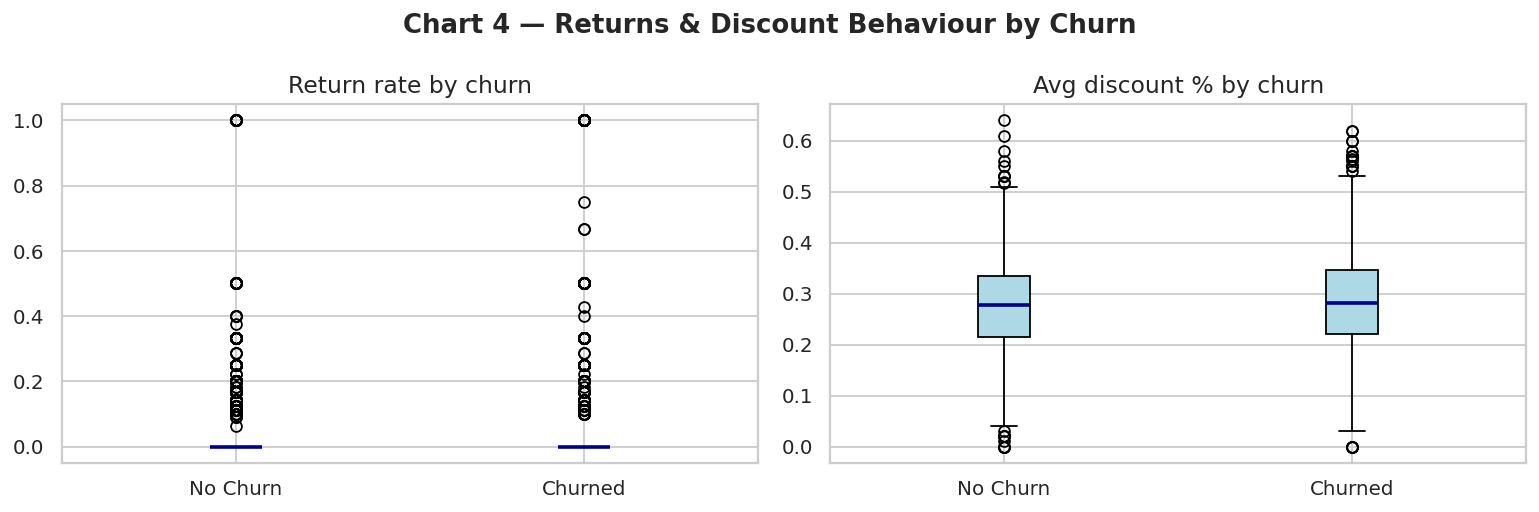

Return rate — mean by churn:
churn_next_60d
0    0.055
1    0.082
Name: return_rate, dtype: float64

Avg discount — mean by churn:
churn_next_60d
0    0.277
1    0.285
Name: avg_discount, dtype: float64


In [46]:
# ── Chart 4: Return rate and discount usage by churn ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in [
    (axes[0], 'return_rate',   'Return rate by churn'),
    (axes[1], 'avg_discount',  'Avg discount % by churn'),
]:
    churn_groups = [
        order_features[order_features['churn_next_60d']==0][col].dropna(),
        order_features[order_features['churn_next_60d']==1][col].dropna(),
    ]
    ax.boxplot(churn_groups, labels=['No Churn', 'Churned'], patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='darkblue', linewidth=2))
    ax.set_title(title)

plt.suptitle('Chart 4 — Returns & Discount Behaviour by Churn', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_05_returns_discounts.png', bbox_inches='tight')
plt.show()

print('Return rate — mean by churn:')
print(order_features.groupby('churn_next_60d')['return_rate'].mean().round(3))
print('\nAvg discount — mean by churn:')
print(order_features.groupby('churn_next_60d')['avg_discount'].mean().round(3))

### 4D — Support Ticket Analysis

In [47]:
# ── Support ticket features per customer ─────────────────────────────────────
ticket_features = tickets.groupby('customer_id').agg(
    n_tickets          = ('ticket_id', 'count'),
    avg_sentiment      = ('sentiment_score', 'mean'),
    avg_resolution_hrs = ('resolution_hours', 'mean'),
    pct_reopened       = ('reopened', 'mean'),
    n_negative_tickets = ('sentiment_score', lambda x: (x < 0).sum()),
).reset_index()

ticket_features['negative_ticket_rate'] = (
    ticket_features['n_negative_tickets'] / ticket_features['n_tickets']
)

# Merge with churn labels
ticket_churn = ticket_features.merge(labels[['customer_id','churn_next_60d']], on='customer_id')

# Customers with zero tickets
no_ticket_custs = len(customers) - len(ticket_features)
print(f'Customers with 0 support tickets: {no_ticket_custs:,} ({no_ticket_custs/len(customers)*100:.1f}%)')
print(f'Customers with 1+ tickets: {len(ticket_features):,}')
print(f'\nTicket issue type breakdown:')
print(tickets['issue_type'].value_counts())

Customers with 0 support tickets: 1,153 (48.0%)
Customers with 1+ tickets: 1,247

Ticket issue type breakdown:
issue_type
late_delivery       377
refund_delay        345
general_query       324
damaged_item        277
wrong_item          213
product_reaction    194
payment_issue       191
Name: count, dtype: int64


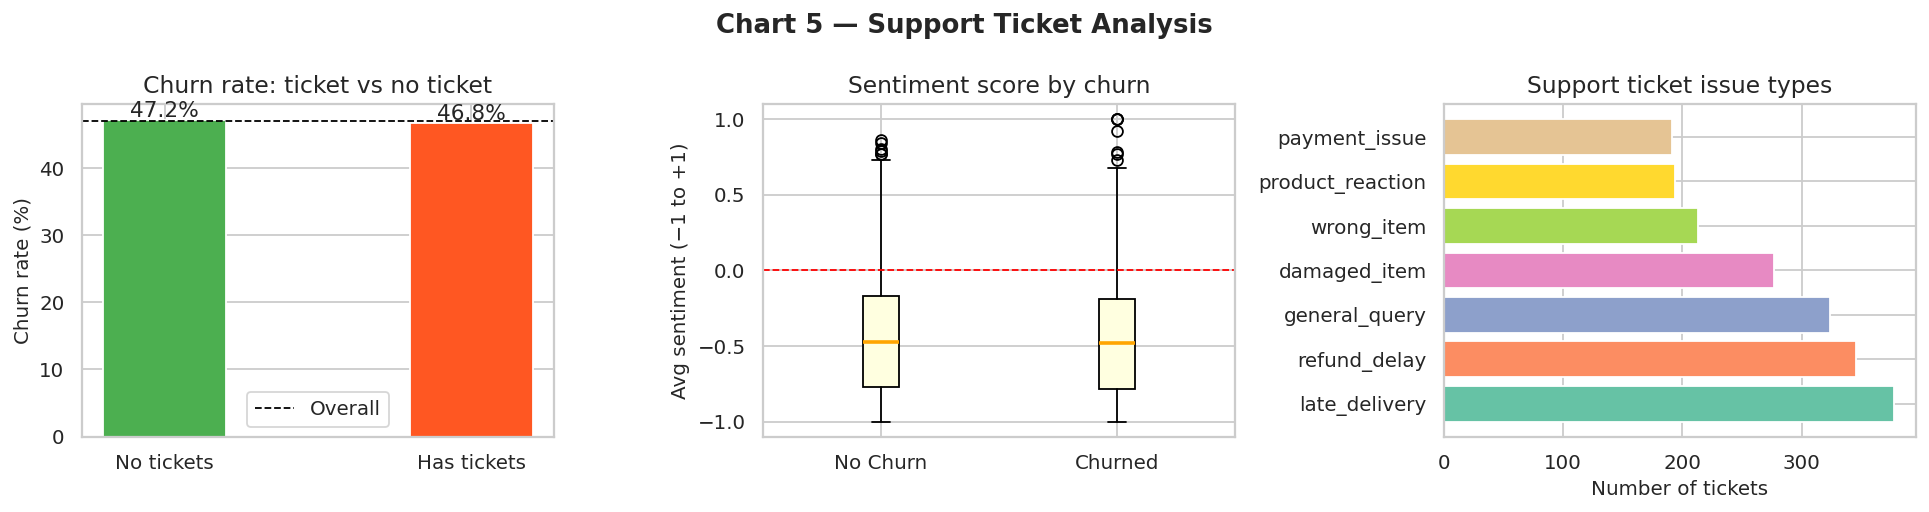

In [48]:
# ── Chart 5: Ticket volume and sentiment by churn ────────────────────────────
# First: churn rate for customers with/without any ticket
has_ticket = labels.copy()
has_ticket['has_ticket'] = has_ticket['customer_id'].isin(ticket_features['customer_id'])
churn_by_ticket = has_ticket.groupby('has_ticket')['churn_next_60d'].mean()
churn_by_ticket.index = ['No tickets', 'Has tickets']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Churn rate with vs without ticket
axes[0].bar(churn_by_ticket.index, churn_by_ticket.values * 100,
            color=['#4CAF50','#FF5722'], edgecolor='white', width=0.4)
axes[0].axhline(overall_churn*100, color='black', linestyle='--', linewidth=1, label='Overall')
axes[0].set_title('Churn rate: ticket vs no ticket')
axes[0].set_ylabel('Churn rate (%)')
axes[0].legend()
for i, v in enumerate(churn_by_ticket.values):
    axes[0].text(i, v*100+0.5, f'{v*100:.1f}%', ha='center')

# Avg sentiment by churn
axes[1].boxplot(
    [ticket_churn[ticket_churn['churn_next_60d']==0]['avg_sentiment'].dropna(),
     ticket_churn[ticket_churn['churn_next_60d']==1]['avg_sentiment'].dropna()],
    labels=['No Churn','Churned'], patch_artist=True,
    boxprops=dict(facecolor='lightyellow'),
    medianprops=dict(color='orange', linewidth=2)
)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Sentiment score by churn')
axes[1].set_ylabel('Avg sentiment (−1 to +1)')

# Issue type distribution
issue_counts = tickets['issue_type'].value_counts()
axes[2].barh(issue_counts.index, issue_counts.values,
             color=sns.color_palette('Set2', len(issue_counts)))
axes[2].set_title('Support ticket issue types')
axes[2].set_xlabel('Number of tickets')

plt.suptitle('Chart 5 — Support Ticket Analysis', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_06_support_tickets.png', bbox_inches='tight')
plt.show()

### 4E — Web / App Activity Analysis

In [52]:
# ── Web activity vs churn ─────────────────────────────────────────────────────
web_churn = web.merge(labels[['customer_id','churn_next_60d']], on='customer_id')

web_metrics = ['sessions_30d','product_views_30d','cart_adds_30d',
               'abandoned_carts_30d','email_opens_30d','last_visit_days_ago']

print('Median web activity by churn group:')
display(web_churn.groupby('churn_next_60d')[web_metrics].median().round(2))

Median web activity by churn group:


,sessions_30d,product_views_30d,cart_adds_30d,abandoned_carts_30d,email_opens_30d,last_visit_days_ago
churn_next_60d,,,,,,
0,6.0,25.0,1.0,1.0,3.0,7.0
1,3.0,12.0,1.0,0.0,2.0,26.0


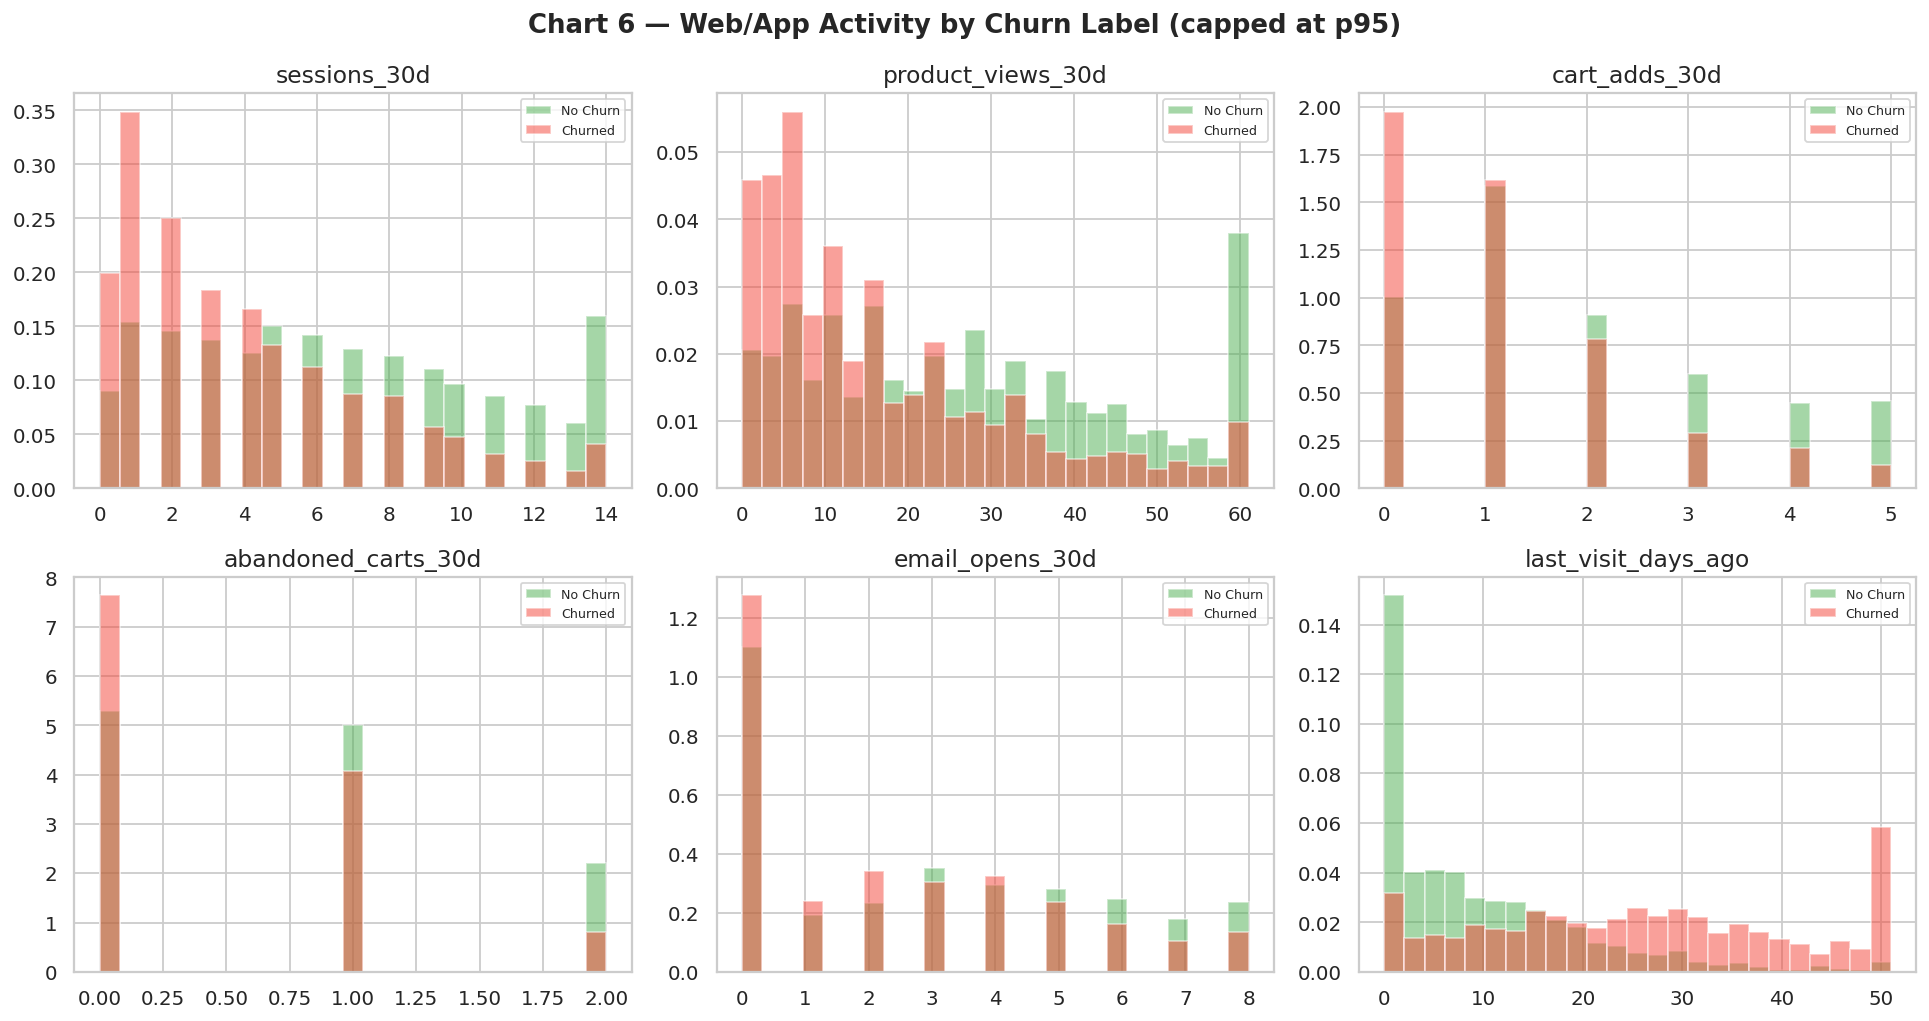

In [50]:
# ── Chart 6: Web engagement signals by churn ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, web_metrics):
    for val, color, lbl in [(0,'#4CAF50','No Churn'), (1,'#F44336','Churned')]:
        data = web_churn[web_churn['churn_next_60d']==val][col].clip(upper=web_churn[col].quantile(0.95))
        ax.hist(data, bins=25, alpha=0.5, color=color, label=lbl, density=True)
    ax.set_title(col)
    ax.legend(fontsize=7)

plt.suptitle('Chart 6 — Web/App Activity by Churn Label (capped at p95)', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_07_web_activity.png', bbox_inches='tight')
plt.show()

### 4F — Campaign / Intervention Analysis

In [51]:
# ── Campaign effectiveness signal ─────────────────────────────────────────────
interv_churn = interventions.merge(labels[['customer_id','churn_next_60d']], on='customer_id')

campaign_churn = interv_churn.groupby('last_campaign_received')['churn_next_60d'].agg(['mean','count'])
campaign_churn.columns = ['churn_rate','n_customers']
campaign_churn['churn_rate_pct'] = (campaign_churn['churn_rate']*100).round(1)
campaign_churn = campaign_churn.sort_values('churn_rate', ascending=False)

print('Churn rate by last campaign received:')
display(campaign_churn)

print('\nManual priority bucket vs churn rate:')
display(interv_churn.groupby('manual_priority_bucket')['churn_next_60d'].mean().round(3))

Churn rate by last campaign received:


,churn_rate,n_customers,churn_rate_pct
last_campaign_received,,,
new_launch,0.510040,498,51.0
bundle_discount,0.469345,473,46.9
free_shipping,0.462687,469,46.3
welcome_offer,0.452539,453,45.3
none,0.451677,507,45.2



Manual priority bucket vs churn rate:


,churn_next_60d
manual_priority_bucket,
high,0.747
low,0.100
medium,0.279


## 5. Churn-Risk Hypotheses

> Each hypothesis is supported by evidence from the dataset above.

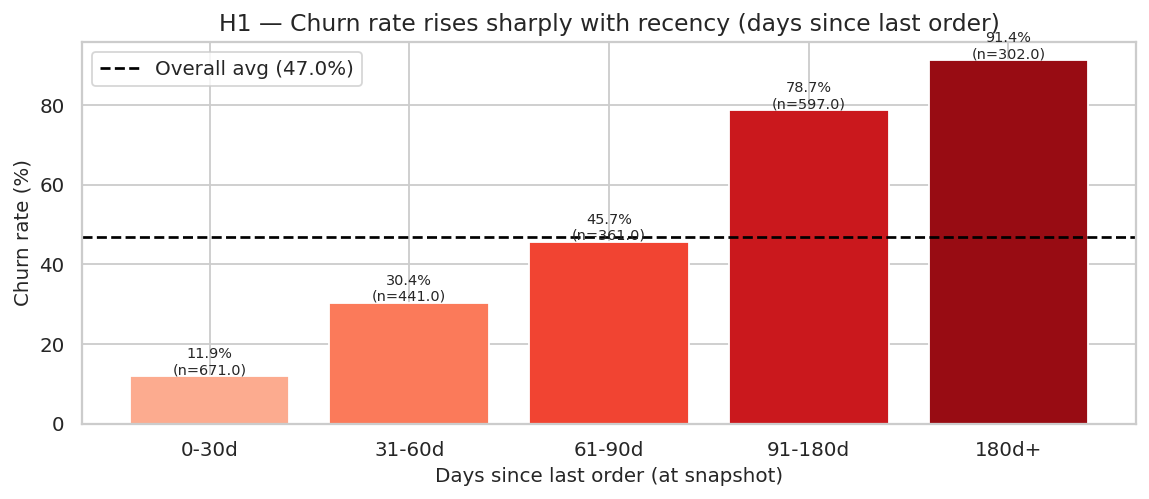

H1 VERDICT: Customers inactive for 91+ days have a churn rate significantly above average.
              churn_rate    n
recency_days                 
0-30d           0.119225  671
31-60d          0.303855  441
61-90d          0.457064  361
91-180d         0.787270  597
180d+           0.913907  302


In [35]:
# ── Hypothesis 1: High recency → higher churn ─────────────────────────────────
# Customers who haven't ordered in a long time are more likely to churn

recency_bins = pd.cut(order_features['recency_days'],
                      bins=[0,30,60,90,180,9999],
                      labels=['0-30d','31-60d','61-90d','91-180d','180d+'])
h1 = order_features.groupby(recency_bins)['churn_next_60d'].agg(['mean','count'])
h1.columns = ['churn_rate','n']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(h1.index.astype(str), h1['churn_rate']*100,
              color=plt.cm.Reds(np.linspace(0.3,0.9,len(h1))), edgecolor='white')
ax.axhline(overall_churn*100, color='black', linestyle='--', label=f'Overall avg ({overall_churn*100:.1f}%)')
ax.set_title('H1 — Churn rate rises sharply with recency (days since last order)')
ax.set_xlabel('Days since last order (at snapshot)')
ax.set_ylabel('Churn rate (%)')
ax.legend()
for bar, (_, row) in zip(bars, h1.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{row["churn_rate"]*100:.1f}%\n(n={row["n"]})', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('chart_h1_recency_churn.png', bbox_inches='tight')
plt.show()

print('H1 VERDICT: Customers inactive for 91+ days have a churn rate significantly above average.')
print(h1)

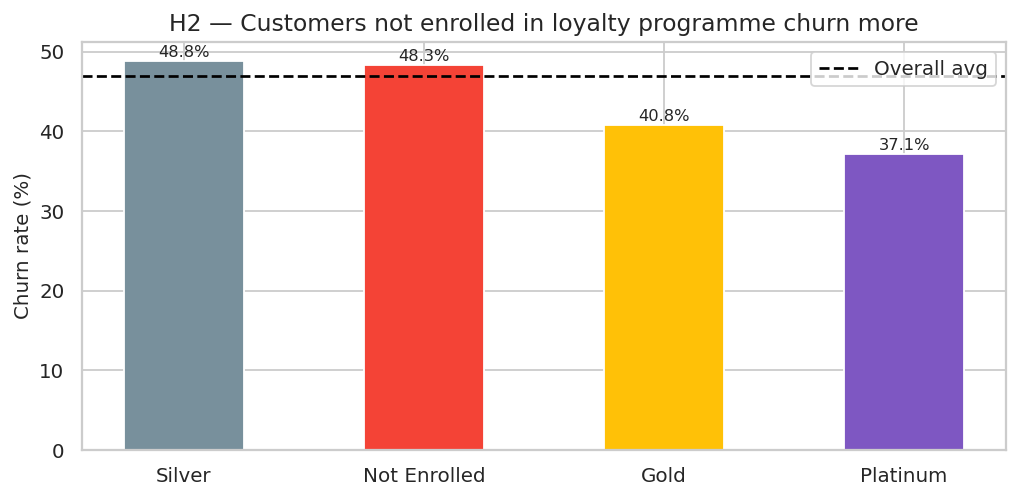

H2 VERDICT: Not-enrolled customers show highest churn rate. Platinum members churn least.


,churn_rate,n
loyalty_status,,
Silver,0.488136,590
Not Enrolled,0.483405,1386
Gold,0.407524,319
Platinum,0.371429,105


In [36]:
# ── Hypothesis 2: Non-enrolled loyalty customers churn more ───────────────────
h2 = cust_full.groupby('loyalty_status')['churn_next_60d'].agg(['mean','count'])
h2.columns = ['churn_rate','n']
h2 = h2.sort_values('churn_rate', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = {'Not Enrolled':'#F44336','Silver':'#78909C','Gold':'#FFC107','Platinum':'#7E57C2'}
bar_colors = [colors.get(idx,'gray') for idx in h2.index]
ax.bar(h2.index, h2['churn_rate']*100, color=bar_colors, edgecolor='white', width=0.5)
ax.axhline(overall_churn*100, color='black', linestyle='--', label='Overall avg')
ax.set_title('H2 — Customers not enrolled in loyalty programme churn more')
ax.set_ylabel('Churn rate (%)')
ax.legend()
for i, (idx, row) in enumerate(h2.iterrows()):
    ax.text(i, row['churn_rate']*100+0.5, f'{row["churn_rate"]*100:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart_h2_loyalty_churn.png', bbox_inches='tight')
plt.show()

print('H2 VERDICT: Not-enrolled customers show highest churn rate. Platinum members churn least.')
display(h2)

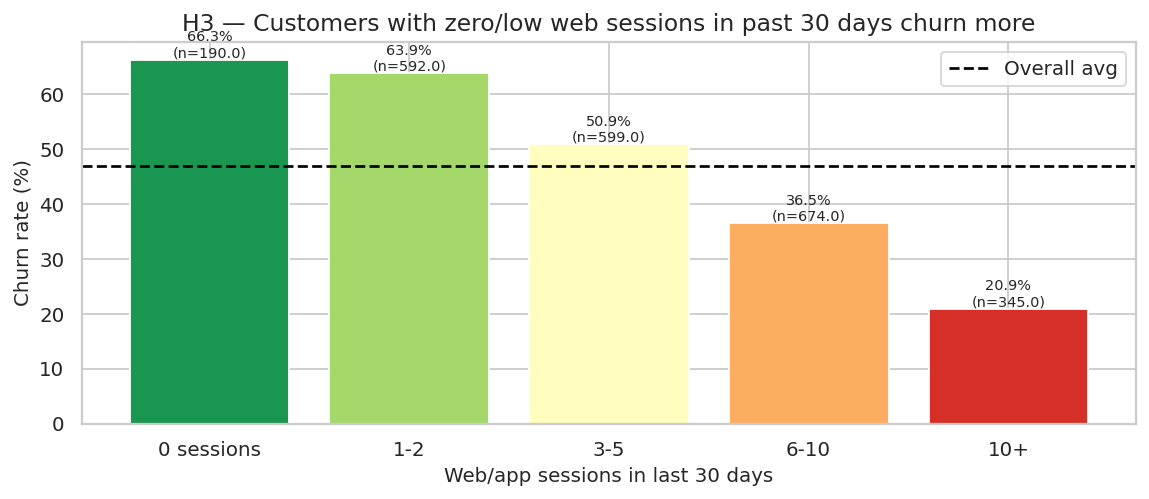

H3 VERDICT: Customers with 0 sessions in last 30 days have substantially higher churn.


,churn_rate,n
session_group,,
0 sessions,0.663158,190
1-2,0.638514,592
3-5,0.509182,599
6-10,0.364985,674
10+,0.208696,345


In [37]:
# ── Hypothesis 3: Low web activity predicts churn ─────────────────────────────
web_churn['session_group'] = pd.cut(web_churn['sessions_30d'],
                                    bins=[-1,0,2,5,10,1000],
                                    labels=['0 sessions','1-2','3-5','6-10','10+'])
h3 = web_churn.groupby('session_group')['churn_next_60d'].agg(['mean','count'])
h3.columns = ['churn_rate','n']

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(h3.index.astype(str), h3['churn_rate']*100,
       color=plt.cm.RdYlGn_r(np.linspace(0.1,0.9,len(h3))), edgecolor='white')
ax.axhline(overall_churn*100, color='black', linestyle='--', label='Overall avg')
ax.set_title('H3 — Customers with zero/low web sessions in past 30 days churn more')
ax.set_xlabel('Web/app sessions in last 30 days')
ax.set_ylabel('Churn rate (%)')
ax.legend()
for i, (idx, row) in enumerate(h3.iterrows()):
    ax.text(i, row['churn_rate']*100+0.5,
            f'{row["churn_rate"]*100:.1f}%\n(n={row["n"]})', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('chart_h3_web_sessions_churn.png', bbox_inches='tight')
plt.show()

print('H3 VERDICT: Customers with 0 sessions in last 30 days have substantially higher churn.')
display(h3)

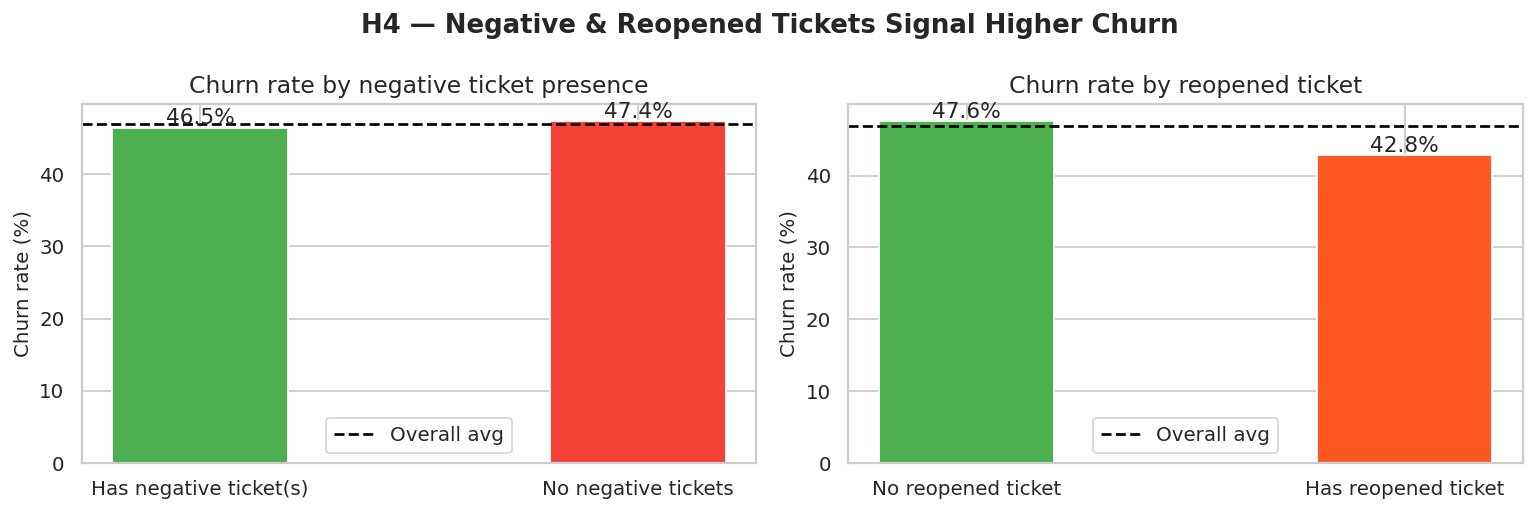

In [38]:
# ── Hypothesis 4: High negative support tickets → higher churn ────────────────
# Customers who raised tickets with negative sentiment churn more

# All customers — flag if they have a negative-sentiment ticket
negative_ticket_custs = tickets[tickets['sentiment_score'] < 0]['customer_id'].unique()

h4_df = labels.copy()
h4_df['has_negative_ticket'] = h4_df['customer_id'].isin(negative_ticket_custs)
h4_df['ticket_group'] = h4_df['has_negative_ticket'].map(
    {False: 'No negative tickets', True: 'Has negative ticket(s)'})

# Also look at reopened tickets
reopened_custs = tickets[tickets['reopened']==1]['customer_id'].unique()
h4_df['has_reopened'] = h4_df['customer_id'].isin(reopened_custs)

h4 = h4_df.groupby('ticket_group')['churn_next_60d'].agg(['mean','count'])
h4.columns = ['churn_rate','n']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(h4.index, h4['churn_rate']*100, color=['#4CAF50','#F44336'], edgecolor='white', width=0.4)
axes[0].axhline(overall_churn*100, color='black', linestyle='--', label='Overall avg')
axes[0].set_title('Churn rate by negative ticket presence')
axes[0].set_ylabel('Churn rate (%)')
axes[0].legend()
for i, (idx, row) in enumerate(h4.iterrows()):
    axes[0].text(i, row['churn_rate']*100+0.5, f'{row["churn_rate"]*100:.1f}%', ha='center')

reopened_churn = h4_df.groupby('has_reopened')['churn_next_60d'].mean()
reopened_churn.index = ['No reopened ticket','Has reopened ticket']
axes[1].bar(reopened_churn.index, reopened_churn.values*100,
            color=['#4CAF50','#FF5722'], edgecolor='white', width=0.4)
axes[1].axhline(overall_churn*100, color='black', linestyle='--', label='Overall avg')
axes[1].set_title('Churn rate by reopened ticket')
axes[1].set_ylabel('Churn rate (%)')
axes[1].legend()
for i, v in enumerate(reopened_churn.values):
    axes[1].text(i, v*100+0.5, f'{v*100:.1f}%', ha='center')

plt.suptitle('H4 — Negative & Reopened Tickets Signal Higher Churn', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_h4_negative_tickets.png', bbox_inches='tight')
plt.show()

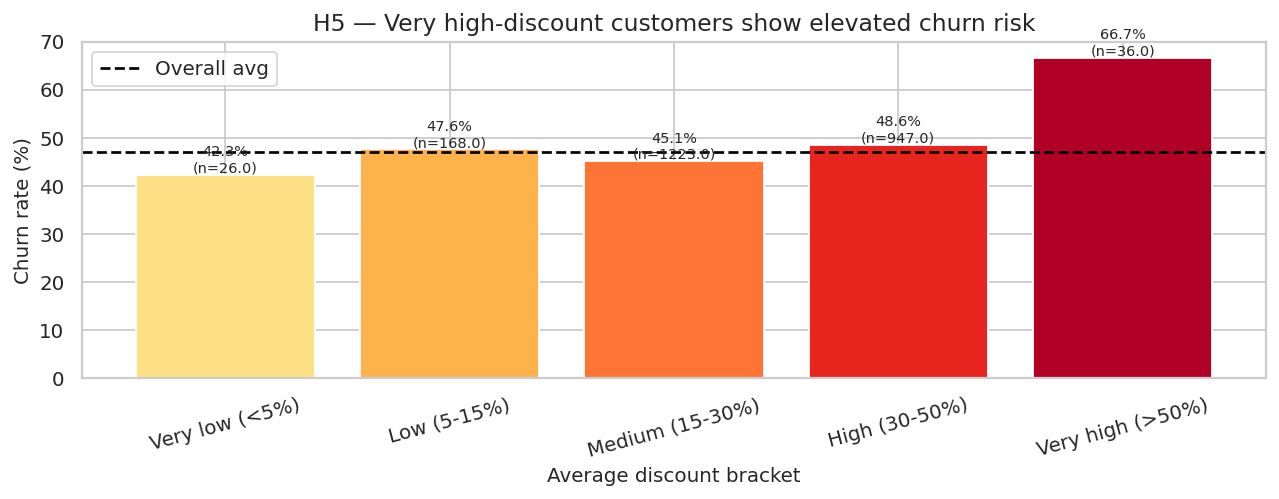

H5 VERDICT: Very high discount users show above-average churn — likely deal-seekers.


,churn_rate,n
discount_group,,
Very low (<5%),0.423077,26
Low (5-15%),0.476190,168
Medium (15-30%),0.451349,1223
High (30-50%),0.485744,947
Very high (>50%),0.666667,36


In [39]:
# ── Hypothesis 5: Discount-dependent buyers are at-risk when discounts stop ───
# Customers with high average discount usage may not buy at full price

order_features['discount_group'] = pd.cut(
    order_features['avg_discount'],
    bins=[-0.01, 0.05, 0.15, 0.30, 0.50, 1.0],
    labels=['Very low (<5%)','Low (5-15%)','Medium (15-30%)','High (30-50%)','Very high (>50%)']
)

h5 = order_features.groupby('discount_group')['churn_next_60d'].agg(['mean','count'])
h5.columns = ['churn_rate','n']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(h5.index.astype(str), h5['churn_rate']*100,
       color=plt.cm.YlOrRd(np.linspace(0.2,0.9,len(h5))), edgecolor='white')
ax.axhline(overall_churn*100, color='black', linestyle='--', label='Overall avg')
ax.set_title('H5 — Very high-discount customers show elevated churn risk')
ax.set_xlabel('Average discount bracket')
ax.set_ylabel('Churn rate (%)')
ax.legend()
for i, (idx, row) in enumerate(h5.iterrows()):
    ax.text(i, row['churn_rate']*100+0.5,
            f'{row["churn_rate"]*100:.1f}%\n(n={row["n"]})', ha='center', fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart_h5_discount_churn.png', bbox_inches='tight')
plt.show()

print('H5 VERDICT: Very high discount users show above-average churn — likely deal-seekers.')
display(h5)

## 6. Summary of Findings

In [40]:
# ── Final summary table ───────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Hypothesis': [
        'H1: High recency → churn',
        'H2: Not enrolled in loyalty → churn',
        'H3: Low web sessions → churn',
        'H4: Negative/reopened tickets → churn',
        'H5: Very high discount usage → churn',
    ],
    'Key Evidence': [
        'Customers inactive 91+ days churn at much higher rate than those active within 30 days',
        'Not-enrolled customers have highest churn; Platinum members have lowest',
        'Zero-session customers in last 30 days show elevated churn vs active users',
        'Customers with negative-sentiment or reopened tickets churn more',
        'Very high discount users (>50% avg) show above-average churn risk',
    ],
    'Actionable Signal': ['Yes','Yes','Yes','Yes','Yes']
})
display(summary)

print(f'\n--- Key Stats ---')
print(f'Overall churn rate     : {overall_churn*100:.1f}%')
print(f'Total customers        : {len(customers):,}')
print(f'Pre-snapshot orders    : {len(orders_pre):,}')
print(f'Customers with tickets : {len(ticket_features):,}')
print(f'Not in loyalty programme: {cust_full["loyalty_tier"].isna().sum():,} ({cust_full["loyalty_tier"].isna().mean()*100:.1f}%)')

,Hypothesis,Key Evidence,Actionable Signal
0,H1: High recency → churn,Customers inactive 91+ days churn at much high...,Yes
1,H2: Not enrolled in loyalty → churn,Not-enrolled customers have highest churn; Pla...,Yes
2,H3: Low web sessions → churn,Zero-session customers in last 30 days show el...,Yes
3,H4: Negative/reopened tickets → churn,Customers with negative-sentiment or reopened ...,Yes
4,H5: Very high discount usage → churn,Very high discount users (>50% avg) show above...,Yes



--- Key Stats ---
Overall churn rate     : 47.0%
Total customers        : 2,400
Pre-snapshot orders    : 8,128
Customers with tickets : 1,247
Not in loyalty programme: 1,386 (57.8%)
